In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [11]:
print("--- LAB 1: Dataset Exploration ---")

# 1. Load Dataset
# อ่านไฟล์ CSV
df = pd.read_csv('Travel_Kayak (2).csv')

# 2. Display Shape
# แสดงรูปร่างของข้อมูล (จำนวนแถว, จำนวนคอลัมน์)
print(f"Shape of dataset: {df.shape}\n")

# 3. Display Data Types
# แสดงชนิดข้อมูลของแต่ละคอลัมน์
print("Data Types:")
print(df.dtypes)
print("\n")

# 4. Display Summary Statistics
# แสดงค่าสถิติเชิงพรรณนา
print("Summary Statistics:")
display(df.describe()) # หากใช้ไฟล์ .py ปกติให้เปลี่ยน display เป็น print
print("\n")

--- LAB 1: Dataset Exploration ---
Shape of dataset: (29, 19)

Data Types:
Unnamed: 0                     int64
brandId                      float64
classification                   str
distinctProviderCount        float64
hid                          float64
localizedHotelName               str
resultId                         str
resultType                       str
stars                        float64
useStarRating                  int64
viewRank                       int64
amenities_count                int64
badges_count                   int64
freebies_count                 int64
providers_count                int64
smartTags_count                int64
brand_name                       str
classification_code_hotel      int64
historic_price               float64
dtype: object


Summary Statistics:


,Unnamed: 0,brandId,distinctProviderCount,hid,stars,useStarRating,viewRank,amenities_count,badges_count,freebies_count,providers_count,smartTags_count,classification_code_hotel,historic_price
count,29.000000,29.00000,29.000000,2.900000e+01,29.000000,29.0,29.000000,29.000000,29.000000,29.000000,29.000000,29.0,29.000000,29.000000
mean,14.000000,326.37931,2.862069,1.131820e+08,3.862069,1.0,14.931034,13.241379,1.000000,0.034483,2.862069,0.0,0.965517,497.701379
std,8.514693,327.52529,1.274030,3.308604e+08,0.742781,0.0,8.631053,3.089789,0.267261,0.185695,1.274030,0.0,0.185695,136.270912
min,0.000000,0.00000,0.000000,0.000000e+00,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,7.000000,48.00000,2.000000,1.707670e+05,4.000000,1.0,8.000000,12.000000,1.000000,0.000000,2.000000,0.0,1.000000,464.840000
50%,14.000000,172.00000,3.000000,2.455068e+06,4.000000,1.0,15.000000,13.000000,1.000000,0.000000,3.000000,0.0,1.000000,499.230000
75%,21.000000,677.00000,4.000000,7.225533e+06,4.000000,1.0,22.000000,15.000000,1.000000,0.000000,4.000000,0.0,1.000000,550.700000
max,28.000000,950.00000,5.000000,1.070693e+09,4.000000,1.0,29.000000,17.000000,2.000000,1.000000,5.000000,0.0,1.000000,882.080000


--- LAB 2: Data Visualization ---


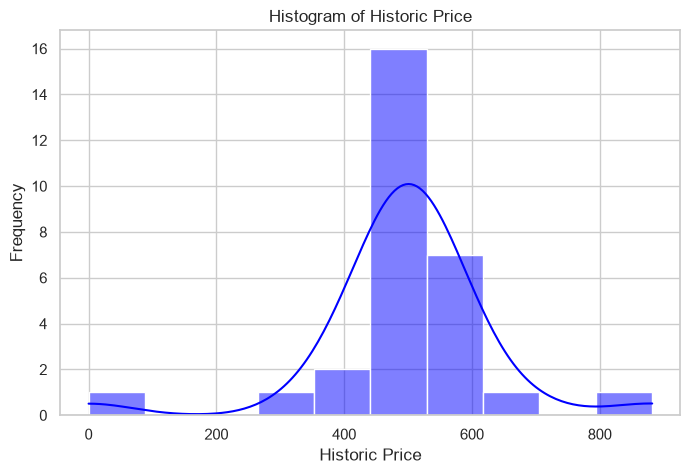

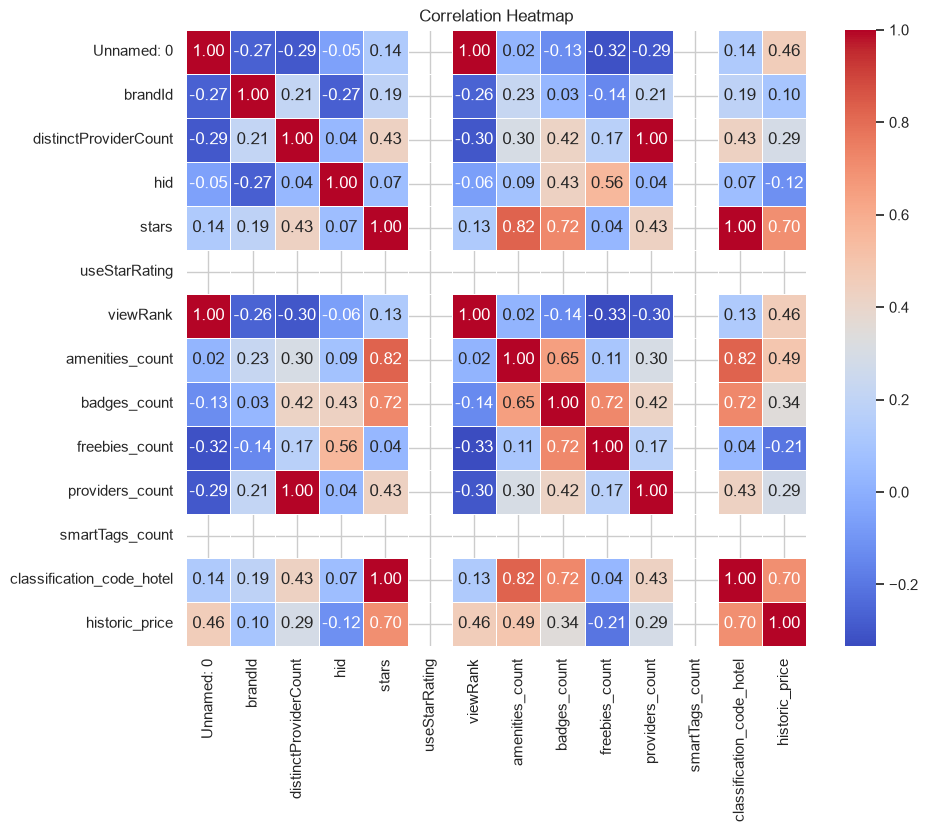

In [12]:
print("--- LAB 2: Data Visualization ---")

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")

# 1. Histogram
# สร้างกราฟ Histogram ดูการกระจายตัวของราคา (historic_price)
plt.figure(figsize=(8, 5))
sns.histplot(df['historic_price'], bins=10, kde=True, color='blue')
plt.title('Histogram of Historic Price')
plt.xlabel('Historic Price')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
# สร้าง Heatmap ดูความสัมพันธ์ระหว่างตัวแปรที่เป็นตัวเลข
plt.figure(figsize=(10, 8))
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขเพื่อหาค่า Correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [13]:
print("--- Part 3: Data Cleaning ---")

# 1. Missing Value Handling
# เติมค่าว่างด้วยค่าเฉลี่ย (Mean) สำหรับคอลัมน์ตัวเลข (ถ้ามี)
# *ในชุดข้อมูลนี้อาจไม่มีค่าว่าง แต่เขียนโค้ดเผื่อไว้ตามโจทย์
for col in numeric_df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

# 2. Duplicate Removal
# ลบข้อมูลที่ซ้ำกันออก
df = df.drop_duplicates()
print("Duplicates removed.\n")

# 3. Incorrect Data Correction
# ลบคอลัมน์ 'Unnamed: 0' ที่มักติดมาตอนเซฟ CSV (เป็นแค่ Index ไม่ใช่ข้อมูลจริง)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.\n")

# 4. Data Type Conversion
# เปลี่ยนชนิดข้อมูล (ตัวอย่าง: เปลี่ยน brandId ให้เป็น int)
if 'brandId' in df.columns:
    df['brandId'] = df['brandId'].astype(int)
    print("Converted 'brandId' to int.\n")

# 5. Compare Mean and Median
# เปรียบเทียบค่าเฉลี่ยและค่ามัธยฐานของราคา
price_mean = df['historic_price'].mean()
price_median = df['historic_price'].median()
print(f"Historic Price - Mean: {price_mean:.2f}")
print(f"Historic Price - Median: {price_median:.2f}\n")

--- Part 3: Data Cleaning ---
Duplicates removed.

Dropped 'Unnamed: 0' column.

Converted 'brandId' to int.

Historic Price - Mean: 497.70
Historic Price - Median: 499.23



In [14]:
print("--- Part 4: Feature Engineering ---")

# 1. Label Encoding
# แปลงข้อมูลหมวดหมู่ (Category) ให้เป็นตัวเลข (ตัวอย่าง: คอลัมน์ resultType)
label_encoder = LabelEncoder()
if 'resultType' in df.columns:
    df['resultType_encoded'] = label_encoder.fit_transform(df['resultType'])
    print("Label Encoded 'resultType':")
    print(df[['resultType', 'resultType_encoded']].head())
    print("\n")

# 2. One-Hot Encoding
# แปลงข้อมูลหมวดหมู่เป็นคอลัมน์ย่อย (ตัวอย่าง: คอลัมน์ brand_name)
# ใช้ pd.get_dummies
df = pd.get_dummies(df, columns=['brand_name'], prefix='brand')
print("One-Hot Encoded 'brand_name' (showing new columns):")
# แสดงเฉพาะคอลัมน์ที่ถูกสร้างขึ้นมาใหม่บางส่วน
new_cols = [col for col in df.columns if 'brand_' in col]
print(df[new_cols].head())

--- Part 4: Feature Engineering ---
Label Encoded 'resultType':
  resultType  resultType_encoded
0       core                   0
1       core                   0
2       core                   0
3       core                   0
4       core                   0


One-Hot Encoded 'brand_name' (showing new columns):
   brand_Doubletree by Hilton  brand_EVEN  brand_Fitzpatrick  brand_Freehand  \
0                        True       False              False           False   
1                       False       False              False           False   
2                       False       False              False           False   
3                       False       False              False           False   
4                       False       False              False           False   

   brand_Highgate  brand_Hilton Garden Inn  brand_Hilton Grand Vacations  \
0           False                    False                         False   
1           False                    False         